In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [46]:
df = pd.read_csv('f_mnist.csv')

In [47]:
import tensorflow
from tensorflow import keras

In [48]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [49]:
import matplotlib.pyplot as plt

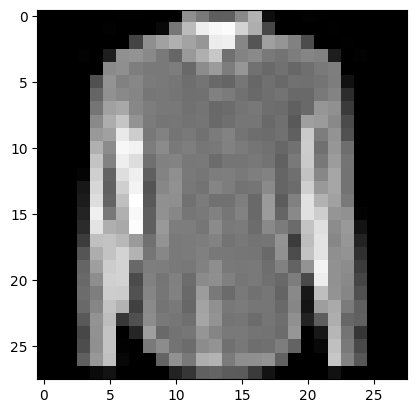

In [50]:
image = X.iloc[13].values.reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
X_train = X_train /255 
X_test = X_test / 255

In [55]:
X_train.shape

(8000, 784)

In [56]:
import matplotlib.pyplot as plt

In [57]:
from keras.layers import Dense,Dropout,Flatten
from keras import Sequential
from keras import regularizers
from keras.callbacks import EarlyStopping

In [58]:
model_adam = Sequential([
    Dense(128, activation='relu',input_shape=(784,),kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

e:\B23AI005\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model_adam.compile(
    optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']
)


In [60]:
callbacks = EarlyStopping(monitor="val_loss",
                          patience=20,
                          min_delta=0.001)

In [61]:
epoch = 200

In [62]:
hist_adam = model_adam.fit(
    X_train, y_train,
    epochs=epoch,
    validation_data=(X_test,y_test),
    callbacks=callbacks
)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6394 - loss: 2.2892 - val_accuracy: 0.7830 - val_loss: 1.3153
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7498 - loss: 1.2161 - val_accuracy: 0.8000 - val_loss: 1.0011
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7696 - loss: 0.9994 - val_accuracy: 0.8120 - val_loss: 0.8622
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7801 - loss: 0.9085 - val_accuracy: 0.8075 - val_loss: 0.8087
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7814 - loss: 0.8747 - val_accuracy: 0.8015 - val_loss: 0.7865
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7771 - loss: 0.8425 - val_accuracy: 0.8045 - val_loss: 0.7515
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7874 - loss: 0.8217 - val_accuracy: 0.8090 - val_loss: 0.7578
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.8046 - val_accu

In [63]:
# rmsprop
model_rmsprop = Sequential([
    Dense(128, activation='relu',input_shape=(784,),kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

e:\B23AI005\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model_rmsprop.compile(
    optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy']
)


In [65]:
hist_rmsprop = model_rmsprop.fit(
    X_train, y_train,
    epochs=epoch,
    validation_data=(X_test,y_test),
    callbacks=callbacks
)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6480 - loss: 2.1922 - val_accuracy: 0.7785 - val_loss: 1.2854
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7483 - loss: 1.1904 - val_accuracy: 0.7980 - val_loss: 0.9399
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7552 - loss: 0.9873 - val_accuracy: 0.7910 - val_loss: 0.8496
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7679 - loss: 0.9035 - val_accuracy: 0.7840 - val_loss: 0.8395
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7695 - loss: 0.8712 - val_accuracy: 0.8125 - val_loss: 0.7708
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7776 - loss: 0.8396 - val_accuracy: 0.8170 - val_loss: 0.7402
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7843 - loss: 0.8178 - val_accuracy: 0.7855 - val_loss: 0.7795
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7857 - loss: 0.7992 - val_accu

In [66]:
#adagrad
model_adagrad = Sequential([
    Dense(128, activation='relu',input_shape=(784,),kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

e:\B23AI005\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
from keras.optimizers import Adagrad,Adadelta

In [94]:
adagrad_optim = Adagrad()
adadelta_optim = Adadelta()

In [95]:
model_adagrad.compile(
    optimizer=adagrad_optim,loss='sparse_categorical_crossentropy',metrics=['accuracy']
)


In [96]:
hist_adagrad = model_adagrad.fit(
    X_train, y_train,
    epochs=1000,
    validation_data=(X_test,y_test),
    callbacks=callbacks
)

Epoch 1/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7147 - loss: 2.7766 - val_accuracy: 0.7810 - val_loss: 2.6115
Epoch 2/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7175 - loss: 2.7136 - val_accuracy: 0.7845 - val_loss: 2.5517
Epoch 3/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7279 - loss: 2.6513 - val_accuracy: 0.7890 - val_loss: 2.4970
Epoch 4/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7366 - loss: 2.5902 - val_accuracy: 0.7930 - val_loss: 2.4463
Epoch 5/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7400 - loss: 2.5372 - val_accuracy: 0.7960 - val_loss: 2.3984
Epoch 6/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7433 - loss: 2.4838 - val_accuracy: 0.7970 - val_loss: 2.3529
Epoch 7/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7395 - loss: 2.4470 - val_accuracy: 0.7960 - val_loss: 2.3102
Epoch 8/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7450 - loss: 2.3963 - 

In [97]:
#adadelta
model_adadelta = Sequential([
    Dense(128, activation='relu',input_shape=(784,),kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

e:\B23AI005\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model_adadelta.compile(
    optimizer=adadelta_optim,loss='sparse_categorical_crossentropy',metrics=['accuracy']
)


In [99]:
hist_adadelta = model_adadelta.fit(
    X_train, y_train,
    epochs=1000,
    validation_data=(X_test,y_test),
    callbacks=callbacks
)

Epoch 1/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0882 - loss: 5.5849 - val_accuracy: 0.0800 - val_loss: 5.4885
Epoch 2/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0960 - loss: 5.5030 - val_accuracy: 0.0950 - val_loss: 5.4151
Epoch 3/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1107 - loss: 5.4354 - val_accuracy: 0.1345 - val_loss: 5.3534
Epoch 4/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1236 - loss: 5.3840 - val_accuracy: 0.1710 - val_loss: 5.2992
Epoch 5/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1392 - loss: 5.3318 - val_accuracy: 0.1995 - val_loss: 5.2505
Epoch 6/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1503 - loss: 5.2905 - val_accuracy: 0.2180 - val_loss: 5.2055
Epoch 7/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1589 - loss: 5.2492 - val_accuracy: 0.2350 - val_loss: 5.1627
Epoch 8/1000
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1730 - loss: 5.2081 - 

In [100]:
res_adagrad = model_adagrad.evaluate(X_test,y_test)
res_adadelta = model_adadelta.evaluate(X_test,y_test)
res_rmsprop = model_rmsprop.evaluate(X_test,y_test)
res_adam = model_adam.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8100 - loss: 1.9012
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.5375 - loss: 4.7298
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8325 - loss: 0.6621  
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.8310 - loss: 0.6324


In [101]:
print(res_adagrad)
print(res_adadelta)
print(res_rmsprop)
print(res_adam)

[1.9011507034301758, 0.8100000023841858]
[4.729770183563232, 0.5375000238418579]
[0.6620800495147705, 0.8324999809265137]
[0.6324158310890198, 0.8309999704360962]


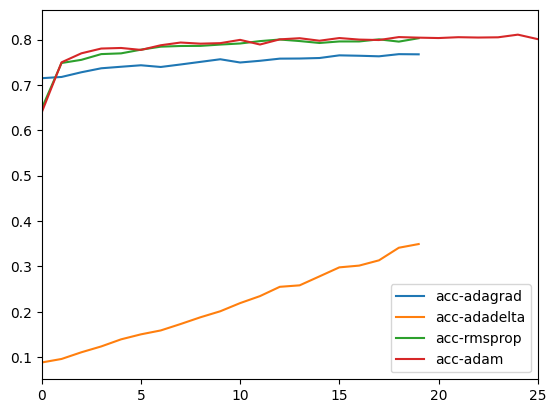

In [102]:
plt.plot(hist_adagrad.history['accuracy'],label="acc-adagrad")
plt.plot(hist_adadelta.history['accuracy'],label="acc-adadelta")
plt.plot(hist_rmsprop.history['accuracy'],label="acc-rmsprop")
plt.plot(hist_adam.history['accuracy'],label="acc-adam")
plt.legend()
plt.xlim(0,25)
plt.show()

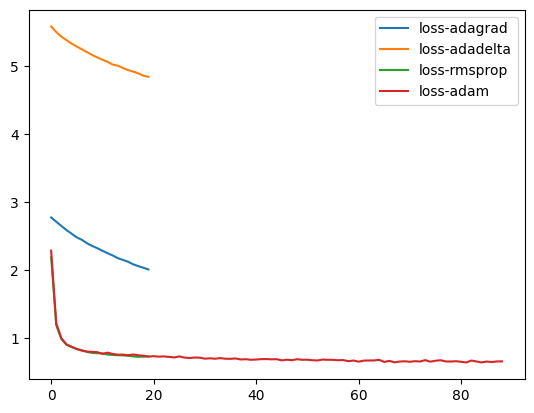

In [104]:
plt.plot(hist_adagrad.history['loss'],label="loss-adagrad")
plt.plot(hist_adadelta.history['loss'],label="loss-adadelta")
plt.plot(hist_rmsprop.history['loss'],label="loss-rmsprop")
plt.plot(hist_adam.history['loss'],label="loss-adam")
plt.legend()
plt.show()